# Phân loại tin tức VietNamNet bằng LinearSVC

**Bài toán**: Phân loại tự động bài báo tiếng Việt vào **19 chủ đề**.

| Bước | Nội dung |
|------|----------|
| **1. Load data** | Đọc 19 file parquet từ thư mục Dataset |
| **2. Khám phá dữ liệu** | Phân bố class, độ dài văn bản, bảng tổng hợp |
| **3. Tiền xử lý** | ViTokenizer + loại stopwords (joblib parallel) |
| **4. TF-IDF** | Vector hóa văn bản đã tokenize |
| **5. Huấn luyện** | LinearSVC C=1.5, class_weight=balanced |
| **6. Đánh giá** | Báo cáo phân loại, ma trận nhầm lẫn, F1 theo từng chủ đề |
| **7. Export** | Đóng gói pipeline suy luận |
| **8. Chẩn đoán** | In ra các tín hiệu cần xem để cải thiện mô hình |

> **Mô hình**: LinearSVC(C=1.5, class_weight='balanced') + TfidfVectorizer(max_features=150 000, ngram_range=(1,2), min_df=2, sublinear_tf=True) 
>
> **Caching**: mỗi bước nặng (tokenize / TF-IDF / train) tự kiểm tra cache .pkl; nếu đã có thì bỏ qua tính toán và load trực tiếp.


---
## Section 0 - Setup
Chạy **mỗi lần** mở notebook.


In [7]:
# -- Kiểm tra thư viện ----------------------------------------------------
import importlib, sys

_REQUIRED = {
    "pandas":     "pandas",
    "numpy":      "numpy",
    "matplotlib": "matplotlib",
    "seaborn":    "seaborn",
    "sklearn":    "scikit-learn",
    "pyvi":       "pyvi",
    "joblib":     "joblib",
    "pyarrow":    "pyarrow",
    "tqdm":       "tqdm",
}

_missing = {pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None}

if _missing:
    print("=" * 60)
    print("  KHÔNG THỂ, TIẾP TỤC -- Thiếu thư viện")
    print("=" * 60)
    print("  Các gói chưa được cài:")
    for _p in sorted(_missing):
        print(f"    - {_p}")
    print()
    _pip = " ".join(sorted(_missing))
    print("  Chạy lệnh sau rồi khởi động lại kernel:")
    print(f"     pip install {_pip}")
    print("=" * 60)
    raise SystemExit("Thiếu thư viện. Xem hướng dẫn ở trên.")

# -- Import ----------------------------------------------------------------
import os, re, pickle, time, datetime, warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("Tất cả thư viện sẵn sàng - Python", sys.version.split()[0])

Tất cả thư viện sẵn sàng - Python 3.13.12


In [8]:
# -- Đường dẫn ------------------------------------------------------------
NOTEBOOK_DIR        = os.getcwd()
DATASET_FOLDER      = os.path.normpath(os.path.join(NOTEBOOK_DIR, "..", "Dataset"))
STOPWORDS_FILE      = os.path.join(NOTEBOOK_DIR, "vietnamese-stopwords.txt")

TEMP_DIR            = os.path.join(NOTEBOOK_DIR, "temp")     # cache trung gian
RESULTS_DIR         = os.path.join(NOTEBOOK_DIR, "results")  # ảnh + report txt
MODEL_DIR           = os.path.join(NOTEBOOK_DIR, "model")    # model dùng cho app

for _d in [TEMP_DIR, RESULTS_DIR, MODEL_DIR]:
    os.makedirs(_d, exist_ok=True)

# temp: cache xử lý nặng (tokenize, tfidf)
PROCESSED_DATA_PATH = os.path.join(TEMP_DIR,  "processed_data.pkl")
TFIDF_DATA_PATH     = os.path.join(TEMP_DIR,  "tfidf_data.pkl")

# model: kết quả training + pipeline đóng gói cho app
MODEL_RESULTS_PATH  = os.path.join(MODEL_DIR, "model_results.pkl")
PIPELINE_PATH       = os.path.join(MODEL_DIR, "inference_pipeline.pkl")

# --
MAX_FEATURES = 150_000
NGRAM_RANGE  = (1, 2)
MIN_DF       = 2
C_VALUE      = 1.5
TEST_SIZE    = 0.15
RANDOM_STATE = 42
CLASS_WEIGHT = "balanced"

# -- Label map ------------------------------------------------------------
LABEL_MAP = {
    "ban-doc":               "Bạn đọc",
    "bao-ve-nguoi-tieu-dung":"Bảo vệ người tiêu dùng",
    "bat-dong-san":          "Bất động sản",
    "chinh-tri":             "Chính trị",
    "cong-nghe":             "Công nghệ",
    "dan-toc-ton-giao":      "Dân tộc - Tôn giáo",
    "doi-song":              "Đời sống",
    "du-lich":               "Du lịch",
    "giao-duc":              "Giáo dục",
    "kinh-doanh":            "Kinh doanh",
    "oto-xe-may":            "Ô tô - Xe máy",
    "phap-luat":             "Pháp luật",
    "suc-khoe":              "Sức khỏe",
    "the-gioi":              "Thế giới",
    "the-thao":              "Thể thao",
    "thi-truong-tieu-dung":  "Thị trường tiêu dùng",
    "thoi-su":               "Thời sự",
    "tuan-viet-nam":         "Tuần Việt Nam",
    "van-hoa-giai-tri":      "Văn hóa - Giải trí",
}

# -- Helpers --------------------------------------------------------------
def log(msg, level="INFO"):
    icons = {"INFO": "[i]", "OK": "[OK]", "WARN": "[!]", "SAVE": "[SAVE]"}
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {icons.get(level,' ')} {msg}")

class timer:
    def __init__(self, label): self.label = label
    def __enter__(self): self.t = time.time(); return self
    def __exit__(self, *_): log(f"{self.label} - {time.time()-self.t:.1f}s", "OK")

def save_fig(fig, filename):
    path = os.path.join(RESULTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    log(f"Đã lưu -> {path}", "SAVE")
    plt.show(); plt.close(fig)

# --
_pq = [f for f in os.listdir(DATASET_FOLDER) if f.endswith(".parquet")] \
      if os.path.exists(DATASET_FOLDER) else []
print(f"[OK] Cấu hình OK  |  {len(LABEL_MAP)} chủ đề  |  {len(_pq)} file parquet")
print(f"\n   Mô hình : LinearSVC  C={C_VALUE}  class_weight={CLASS_WEIGHT}  ")
print(f"   TF-IDF  : max_features={MAX_FEATURES:,}  ngram={NGRAM_RANGE}  min_df={MIN_DF}")
print(f"\n   Cache:")
for _name, _path in [("temp/processed_data.pkl",      PROCESSED_DATA_PATH),
                      ("temp/tfidf_data.pkl",           TFIDF_DATA_PATH),
                      ("model/model_results.pkl",       MODEL_RESULTS_PATH),
                      ("model/inference_pipeline.pkl",  PIPELINE_PATH)]:
    print(f"     {_name:<30}: {'[OK]' if os.path.exists(_path) else '[LỖI] chưa có'}")

[OK] Cấu hình OK  |  19 chủ đề  |  19 file parquet

   Mô hình : LinearSVC  C=1.5  class_weight=balanced  
   TF-IDF  : max_features=150,000  ngram=(1, 2)  min_df=2

   Cache:
     temp/processed_data.pkl       : [LỖI] chưa có
     temp/tfidf_data.pkl           : [LỖI] chưa có
     model/model_results.pkl       : [LỖI] chưa có
     model/inference_pipeline.pkl  : [LỖI] chưa có


In [9]:
# -- Kiểm tra Dataset trước khi chạy -------------------------------------
import pyarrow.parquet as _pq_check

_ok = True
_errors = []

# 1. Thư mục Dataset tồn tại
if not os.path.isdir(DATASET_FOLDER):
    _errors.append(f"[LỖI] Không tìm thấy thư mục Dataset: {DATASET_FOLDER}")
    _ok = False
else:
    # 2. Số file parquet phải đúng bằng LABEL_MAP
    _pq_files = sorted(f for f in os.listdir(DATASET_FOLDER) if f.endswith('.parquet'))
    _expected = set(LABEL_MAP.keys())
    _found    = {f.replace('.parquet','') for f in _pq_files}
    _missing  = _expected - _found
    _extra    = _found - _expected

    if _missing:
        _errors.append(f"[LỖI] Thiếu {len(_missing)} file parquet: {sorted(_missing)}")
        _ok = False
    if len(_found) != len(_expected):
        _errors.append(f"[LỖI] Cần {len(_expected)} file, tìm thấy {len(_found)} file")
        _ok = False

    # 3. Từng file phải có dữ liệu (không rỗng)
    if _ok:
        for _f in _pq_files:
            _path = os.path.join(DATASET_FOLDER, _f)
            try:
                _meta = _pq_check.read_metadata(_path)
                if _meta.num_rows == 0:
                    _errors.append(f"[LỖI] File rỗng (0 dòng): {_f}")
                    _ok = False
            except Exception as _e:
                _errors.append(f"[LỖI] Không đọc được {_f}: {_e}")
                _ok = False

# 4. File stopwords tồn tại
if not os.path.isfile(STOPWORDS_FILE):
    _errors.append(f"[LỖI] Không tìm thấy file stopwords: {STOPWORDS_FILE}")
    _ok = False

# Kết quả
if _ok:
    print(f"[OK] Dataset OK - {len(_pq_files)} file parquet, tất cả có dữ liệu")
    print(f"[OK] Stopwords OK - {STOPWORDS_FILE}")
else:
    print("\n" + "="*60)
    print("  KHÔNG THỂ TIẾP TỤC - Dataset chưa sẵn sàng")
    print("="*60)
    for _e in _errors:
        print(f"  {_e}")
    print("\n  Hãy chạy Crawling Data/crawl_data.ipynb để tạo Dataset trước.")
    print("="*60 + "\n")
    raise SystemExit("Dataset chưa sẵn sàng. Xem hướng dẫn ở trên.")

[OK] Dataset OK - 19 file parquet, tất cả có dữ liệu
[OK] Stopwords OK - c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\vietnamese-stopwords.txt


---
## Section 1 - Load Dữ Liệu Thô

Đọc toàn bộ **19 file parquet** từ thư mục Dataset.

In [10]:
# -- 1.1 Load dữ liệu thô -------------------------------------------------
log(f"Đọc {len(LABEL_MAP)} file parquet từ {DATASET_FOLDER}...")
_records = []
for _fname in sorted(os.listdir(DATASET_FOLDER)):
    if not _fname.endswith(".parquet"): continue
    _lbl = LABEL_MAP.get(_fname.replace(".parquet", ""))
    if _lbl is None: continue
    _dfc = pd.read_parquet(os.path.join(DATASET_FOLDER, _fname))
    _dfc["label"] = _lbl
    log(f"  {_fname:<48}  {len(_dfc):>7,} bài  [{_lbl}]")
    _records.append(_dfc)

df_raw = pd.concat(_records, ignore_index=True)
log(f"Tổng raw: {len(df_raw):,} bài | {df_raw['label'].nunique()} chủ đề", "OK")

# --
_miss_title   = df_raw["title"].isna()   | (df_raw["title"].astype(str).str.strip()   == "")
_miss_content = df_raw["content"].isna() | (df_raw["content"].astype(str).str.strip() == "")
_miss_both    = _miss_title & _miss_content   # chỉ loại khi thiếu CẢ HAI

# --
print(f"\n   [Kiểm tra chất lượng dữ liệu]")
print(f"   Thiếu title           : {_miss_title.sum():,} bài")
print(f"   Thiếu content         : {_miss_content.sum():,} bài")
print(f"   Thiếu cả 2 (bị loại)  : {_miss_both.sum():,} bài")

if _miss_both.any():
    _df_miss = df_raw[_miss_both]
    print(f"\n   Phân bố {_miss_both.sum():,} bài bị loại theo chủ đề:\n")
    print(f"   {'Chủ đề':<38}  {'Số bài bị loại':>14}")
    print(f"   {'-'*55}")
    for _cls, _cnt in _df_miss["label"].value_counts().sort_index().items():
        print(f"   {_cls:<38}  {_cnt:>14,}")
    df_raw = df_raw[~_miss_both].reset_index(drop=True)
    log(f"Sau khi loại: {len(df_raw):,} bài còn lại", "OK")
else:
    print(f"\n[OK] Không có bài nào thiếu cả title lẫn content.")

# --
df_raw["title"]    = df_raw["title"].fillna("").astype(str).str.strip()
df_raw["content"]  = df_raw["content"].fillna("").astype(str).str.strip()
df_raw["text_len"] = (df_raw["title"] + " " + df_raw["content"]).str.split().str.len()

print(f"\n   Cột dữ liệu : {list(df_raw.columns)}")
print(f"   Tổng cuối   : {len(df_raw):,} bài")

[11:25:25] [i] Đọc 19 file parquet từ c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\Dataset...
[11:25:25] [i]   ban-doc.parquet                                    12,506 bài  [Bạn đọc]
[11:25:25] [i]   bao-ve-nguoi-tieu-dung.parquet                      3,873 bài  [Bảo vệ người tiêu dùng]
[11:25:26] [i]   bat-dong-san.parquet                               12,506 bài  [Bất động sản]
[11:25:26] [i]   chinh-tri.parquet                                  12,506 bài  [Chính trị]
[11:25:26] [i]   cong-nghe.parquet                                  12,506 bài  [Công nghệ]
[11:25:26] [i]   dan-toc-ton-giao.parquet                            3,355 bài  [Dân tộc - Tôn giáo]
[11:25:26] [i]   doi-song.parquet                                   12,506 bài  [Đời sống]
[11:25:26] [i]   du-lich.parquet                                    10,683 bài  [Du lịch]
[11:25:27] [i]   giao-duc.parquet                                   12,506 bài  [Giáo dục]
[11:25:27] [i]   kinh-doanh.parquet         

---
## Section 2 - Khám Phá Dữ Liệu (EDA)

Phân tích phân bố class, độ dài văn bản, thống kê tổng hợp.

[11:25:44] [SAVE] Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\results\01_class_distribution.png


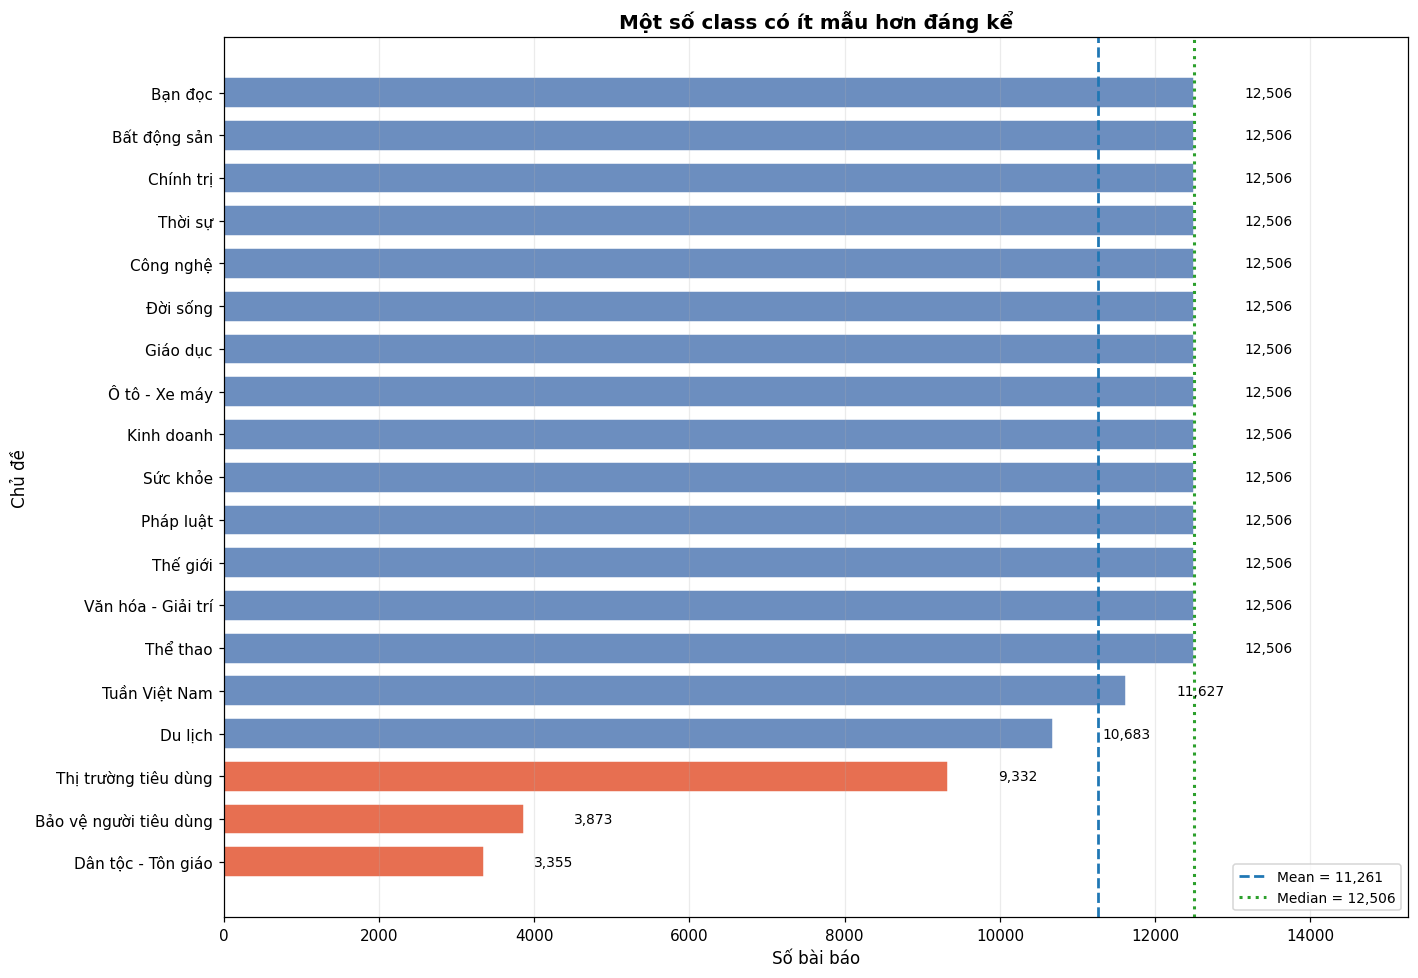


  Tổng mẫu: 213,954
  Nhiều nhất: Bạn đọc                          12,506
  Ít nhất   : Dân tộc - Tôn giáo                3,355
  Imbalance : 3.73x


In [11]:
# -- 2.1 Phan bo class (1 chart = 1 cau hoi) ----------------------------------
_vc = df_raw["label"].value_counts().sort_values(ascending=False)
_total = int(_vc.sum())
_mean = float(_vc.mean())
_median = float(_vc.median())
_warn_thr = _median * 0.75

_colors = ["#e76f51" if v < _warn_thr else "#6c8ebf" for v in _vc.values]

fig, ax = plt.subplots(figsize=(13, 9))
_bars = ax.barh(_vc.index, _vc.values, color=_colors, edgecolor="white", height=0.72)
ax.invert_yaxis()

if len(_vc) <= 25:
    for bar, n in zip(_bars, _vc.values):
        ax.text(bar.get_width() + _total * 0.003,
                bar.get_y() + bar.get_height()/2,
                f"{n:,}", va="center", fontsize=9)

ax.axvline(_mean, color="#1f77b4", ls="--", lw=1.8, label=f"Mean = {_mean:,.0f}")
ax.axvline(_median, color="#2ca02c", ls=":", lw=2.0, label=f"Median = {_median:,.0f}")
ax.set_xlim(0, _vc.max() * 1.22)
ax.set_xlabel("Số bài báo", fontsize=11)
ax.set_ylabel("Chủ đề", fontsize=11)
ax.set_title("Một số class có ít mẫu hơn đáng kể", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
save_fig(fig, "01_class_distribution.png")

_ir = _vc.max() / _vc.min()
print(f"\n  Tổng mẫu: {_total:,}")
print(f"  Nhiều nhất: {_vc.idxmax():<30} {_vc.max():>8,}")
print(f"  Ít nhất   : {_vc.idxmin():<30} {_vc.min():>8,}")
print(f"  Imbalance : {_ir:.2f}x")


[11:25:59] [SAVE] Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\results\02_text_length.png


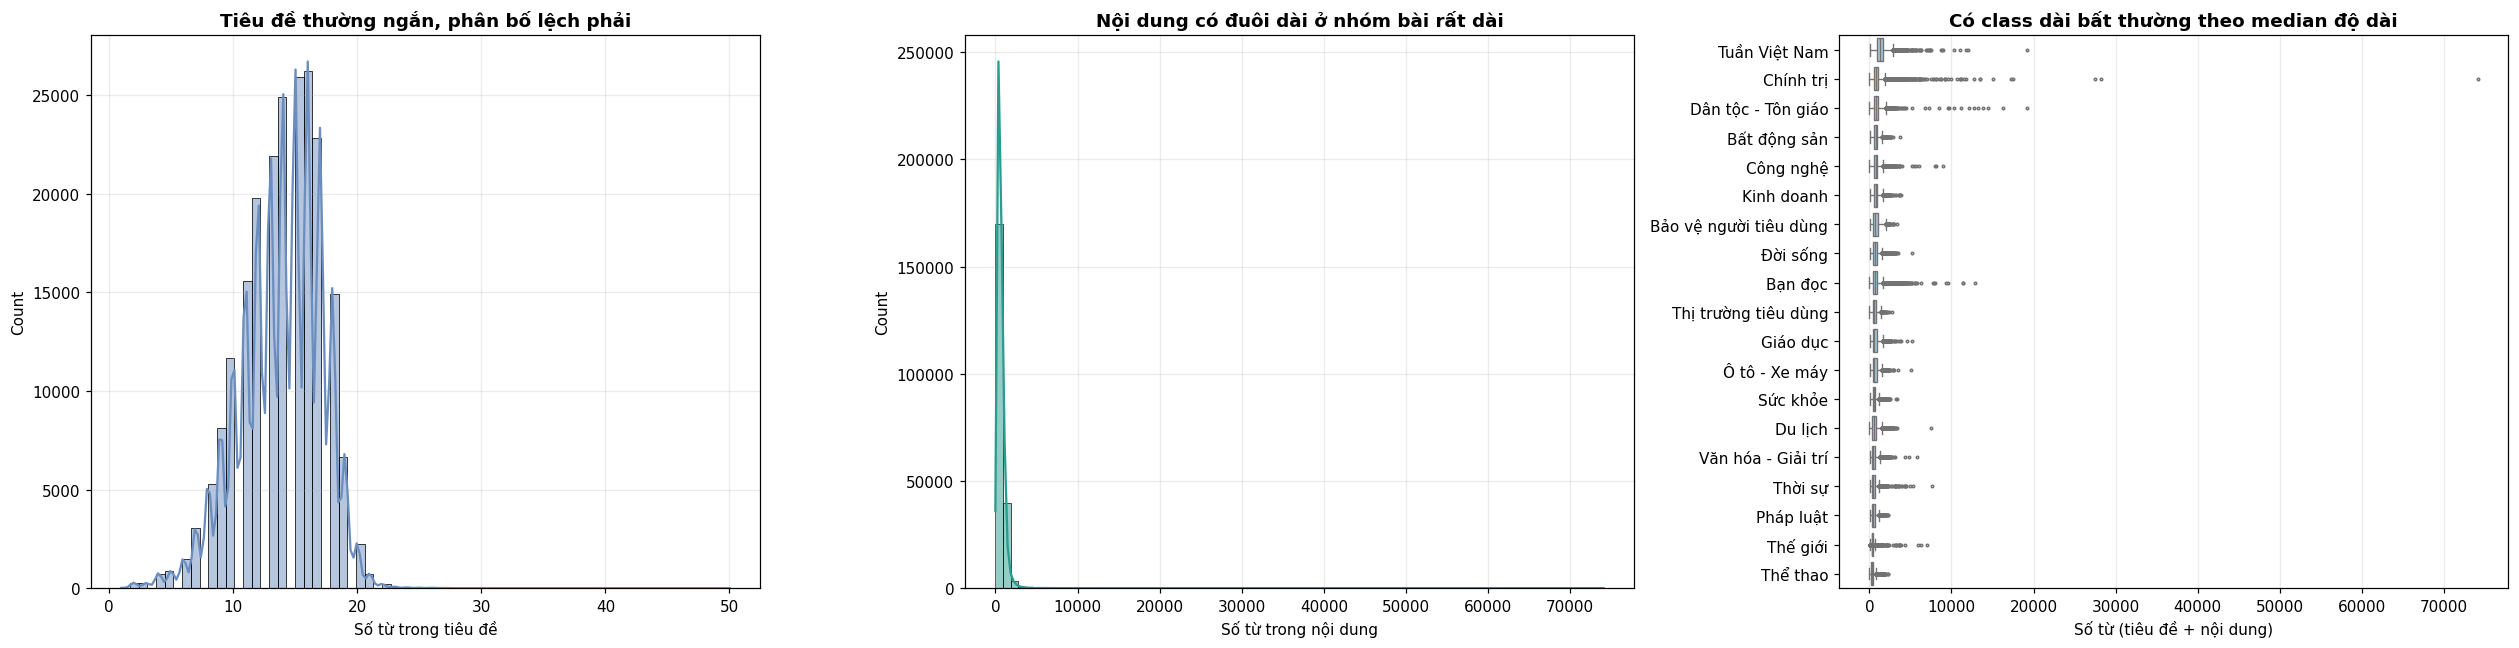


  [Text length percentiles]
  p50 : 586.0
  p90 : 1,162.7
  p95 : 1,427.0
  max : 74,090.0


In [12]:
# -- 2.2 Độ dài văn bản ---------------------------------------------------------
_title_len = df_raw["title"].fillna("").astype(str).str.split().str.len()
_content_len = df_raw["content"].fillna("").astype(str).str.split().str.len()
_text_len = df_raw["text_len"]

fig, axes = plt.subplots(1, 3, figsize=(23, 6))

sns.histplot(_title_len, bins=70, kde=True, color="#6c8ebf", ax=axes[0])
axes[0].set_title("Tiêu đề thường ngắn, phân bố lệch phải", fontweight="bold")
axes[0].set_xlabel("Số từ trong tiêu đề")
axes[0].grid(alpha=0.25)

sns.histplot(_content_len, bins=80, kde=True, color="#2a9d8f", ax=axes[1])
axes[1].set_title("Nội dung có đuôi dài ở nhóm bài rất dài", fontweight="bold")
axes[1].set_xlabel("Số từ trong nội dung")
axes[1].grid(alpha=0.25)

_cls_med = (df_raw.groupby("label")["text_len"].median().sort_values(ascending=False))
_ord = list(_cls_med.index)
sns.boxplot(data=df_raw, y="label", x="text_len", order=_ord, orient="h",
            ax=axes[2], color="#9ecae1", fliersize=1.6, linewidth=0.9)
axes[2].set_title("Có class dài bất thường theo median độ dài", fontweight="bold")
axes[2].set_xlabel("Số từ (tiêu đề + nội dung)")
axes[2].set_ylabel("")
axes[2].grid(axis="x", alpha=0.25)

fig.tight_layout()
save_fig(fig, "02_text_length.png")

print("\n  [Text length percentiles]")
print(f"  p50 : {_text_len.quantile(0.50):,.1f}")
print(f"  p90 : {_text_len.quantile(0.90):,.1f}")
print(f"  p95 : {_text_len.quantile(0.95):,.1f}")
print(f"  max : {_text_len.max():,.1f}")


In [13]:
# --
_rows = []
for _cls in sorted(df_raw["label"].unique()):
    _sub = df_raw[df_raw["label"] == _cls]["text_len"]
    _rows.append({
        "Chủ đề":      _cls,
        "Số bài":      len(_sub),
        "Tỷ lệ %":     round(len(_sub) / len(df_raw) * 100, 2),
        "TB từ":       round(_sub.mean(), 0),
        "Median từ":   round(_sub.median(), 0),
        "Min từ":      int(_sub.min()),
        "Max từ":      int(_sub.max()),
    })
_df_sum = (pd.DataFrame(_rows)
             .sort_values("Số bài", ascending=False)
             .reset_index(drop=True))
_df_sum.index += 1

print("BẢNG TỔNG HỢP DỮ LIỆU\n")
display(
    _df_sum.style
    .background_gradient(subset=["Số bài"], cmap="Blues")
    .background_gradient(subset=["TB từ"], cmap="Greens")
    .format({"Số bài": "{:,}", "Tỷ lệ %": "{:.2f}%", "TB từ": "{:.0f}", "Median từ": "{:.0f}"})
) 

BẢNG TỔNG HỢP DỮ LIỆU



,Chủ đề,Số bài,Tỷ lệ %,TB từ,Median từ,Min từ,Max từ
1,Bạn đọc,"12,506",5.85%,689,670,7,12921
2,Bất động sản,"12,506",5.85%,755,771,18,3750
3,Chính trị,"12,506",5.85%,957,822,4,74090
4,Đời sống,"12,506",5.85%,710,687,14,5131
5,Công nghệ,"12,506",5.85%,788,760,10,8906
6,Kinh doanh,"12,506",5.85%,779,759,40,3800
7,Giáo dục,"12,506",5.85%,665,609,16,5218
8,Pháp luật,"12,506",5.85%,469,391,20,2323
9,Sức khỏe,"12,506",5.85%,600,573,14,3350
10,Thể thao,"12,506",5.85%,374,314,11,2310


---
## Section 3 - Tiền Xử Lý Văn Bản

**Các bước**: làm sạch -> ViTokenizer (song song) -> loại stopwords -> lưu cache.

- Cell 3.1: tokenize toàn bộ corpus, lưu `processed_data.pkl` *(nặng, ~20-40 phút; bỏ qua nếu cache đã có)*
- Cell 3.2: load dữ liệu đã xử lý vào bộ nhớ *(luôn chạy)*

In [14]:
# -- 3.1 Tokenize + lưu cache --------------------------------------------
# --
with open(STOPWORDS_FILE, encoding="utf-8") as _f:
    STOPWORDS = frozenset(line.strip() for line in _f if line.strip())
log(f"Đã tải stopwords: {len(STOPWORDS):,}", "OK")

if os.path.exists(PROCESSED_DATA_PATH):
    print(f"[OK] Cache tồn tại: {PROCESSED_DATA_PATH} - bỏ qua tokenization")
else:
    log("Bắt đầu tiền xử lý văn bản...")

    # Ghép title (x3) + content để tăng trọng số tiêu đề
    df_proc = df_raw[["label"]].copy()
    df_proc["full_text"] = (df_raw["title"] + " " + df_raw["title"]
                            + " " + df_raw["title"] + " " + df_raw["content"])
    df_proc = df_proc[df_proc["full_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Văn bản hợp lệ: {len(df_proc):,}", "OK")

    # Hàm tokenize một văn bản (import bên trong vì chạy trong subprocess riêng)
    def _clean_one(text, sw_list):
        from pyvi import ViTokenizer
        import re
        sw = set(sw_list)
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r"[^\w\s]", " ", text)
        text = re.sub(r"\d+", " ", text)
        text = ViTokenizer.tokenize(text)
        return re.sub(r"\s+", " ",
                      " ".join(t for t in text.split() if t not in sw)).strip()

    from joblib import Parallel, delayed
    from multiprocessing import cpu_count
    _sw_list = list(STOPWORDS)
    log(f"Tokenize song song {len(df_proc):,} bài | {cpu_count()} CPU cores...")
    df_proc["clean_text"] = Parallel(n_jobs=min(cpu_count() // 2, 8), backend="loky", verbose=1, pre_dispatch="2*n_jobs")(
        delayed(_clean_one)(t, _sw_list) for t in df_proc["full_text"].tolist()
    )
    df_proc = df_proc[df_proc["clean_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Sau tokenization: {len(df_proc):,} bài", "OK")

    _classes  = sorted(df_proc["label"].unique().tolist())
    _label2id = {l: i for i, l in enumerate(_classes)}
    _id2label = {i: l for l, i in _label2id.items()}
    df_proc["label_id"] = df_proc["label"].map(_label2id)

    with timer("Lưu processed_data.pkl"):
        with open(PROCESSED_DATA_PATH, "wb") as _f:
            pickle.dump({
                "df":        df_proc,
                "label2id":  _label2id,
                "id2label":  _id2label,
                "stopwords": sorted(STOPWORDS),   # lưu để dùng khi export pipeline
            }, _f)
    log(f"Đã lưu ({os.path.getsize(PROCESSED_DATA_PATH)/1e6:.1f} MB)", "SAVE")

[11:26:00] [OK] Đã tải stopwords: 1,959
[11:26:00] [i] Bắt đầu tiền xử lý văn bản...
[11:26:00] [OK] Văn bản hợp lệ: 213,954
[11:26:00] [i] Tokenize song song 213,954 bài | 24 CPU cores...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done 1800 tasks      | elapsed:    4.9s
[Parallel(n_jobs=8)]: Done 5800 tasks      | elapsed:   10.7s
[Parallel(n_jobs=8)]: Done 11400 tasks      | elapsed:   20.1s
[Parallel(n_jobs=8)]: Done 18600 tasks      | elapsed:   32.9s
[Parallel(n_jobs=8)]: Done 27400 tasks      | elapsed:   47.6s
[Parallel(n_jobs=8)]: Done 37800 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done 49800 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done 63400 tasks      | elapsed:  2.0min
[Parallel(n_jobs=8)]: Done 78600 tasks      | elapsed:  2.4min
[Parallel(n_jobs=8)]: Done 110664 tasks      | elapsed:  3.3min
[Parallel(n_jobs=8)]: Done 147464 tasks      | elapsed:  4.1min
[Parallel(n_jobs=8)]: Done 187464 tasks      | elapsed:  4.9min
[Parallel(n_jobs=8)]: Done 198424 tasks      | elapsed:  5.5min
[Parallel(n_jobs=8)]: Done 213939 out of 21

[11:31:51] [OK] Sau tokenization: 213,954 bài
[11:31:53] [OK] Lưu processed_data.pkl - 2.2s
[11:31:53] [SAVE] Đã lưu (1471.0 MB)


In [15]:
# -- 3.2 Load processed data ---------------------------------------------
with timer("Load processed_data.pkl"):
    with open(PROCESSED_DATA_PATH, "rb") as f:
        _s = pickle.load(f)

df       = _s["df"]
label2id = _s["label2id"]
id2label = _s["id2label"]
classes  = sorted(df["label"].unique().tolist())

# Đảm bảo STOPWORDS luôn có trong scope (phòng trường hợp bỏ qua Cell 3.1)
if "STOPWORDS" not in dir():
    STOPWORDS = frozenset(_s.get("stopwords", []))

_vc3 = df["label"].value_counts()
print(f"[OK] Processed data: {len(df):,} bài | {len(classes)} chủ đề\n")
print(f"   {'Chủ đề':<38}  {'Bài':>8}  {'%':>5}  TB tokens")
print(f"   {'-'*60}")
for _cls in classes:
    _n   = _vc3.get(_cls, 0)
    _tlen = df[df["label"] == _cls]["clean_text"].str.split().str.len().mean()
    print(f"   {_cls:<38}  {_n:>8,}  {_n/len(df)*100:>4.1f}%  {_tlen:>6.0f}")

[11:31:59] [OK] Load processed_data.pkl - 6.2s
[OK] Processed data: 213,954 bài | 19 chủ đề

   Chủ đề                                       Bài      %  TB tokens
   ------------------------------------------------------------
   Bạn đọc                                   12,506   5.8%     309
   Bảo vệ người tiêu dùng                     3,873   1.8%     318
   Bất động sản                              12,506   5.8%     330
   Chính trị                                 12,506   5.8%     396
   Công nghệ                                 12,506   5.8%     318
   Du lịch                                   10,683   5.0%     274
   Dân tộc - Tôn giáo                         3,355   1.6%     388
   Giáo dục                                  12,506   5.8%     273
   Kinh doanh                                12,506   5.8%     326
   Pháp luật                                 12,506   5.8%     225
   Sức khỏe                                  12,506   5.8%     255
   Thế giới                         

---
## Section 4 - Trích Xuất Đặc Trưng (TF-IDF)

`TfidfVectorizer(max_features=150 000, ngram_range=(1,2), min_df=2, sublinear_tf=True)`

In [16]:
# -- 4.1 Fit TF-IDF + chia train/test + lưu cache ------------------------
if os.path.exists(TFIDF_DATA_PATH):
    print(f"[OK] Cache tồn tại: {TFIDF_DATA_PATH}")
    print("   - Bỏ qua TF-IDF, tự động load ở Cell 4.2")
else:
    log(f"Chia train/test ({int(TEST_SIZE*100)}% test, stratified)...")
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        df["clean_text"], df["label"],
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["label"]
    )
    log(f"Train: {len(X_tr_raw):,}  |  Test: {len(X_te_raw):,}", "OK")

    log(f"Khớp TF-IDF - max_features={MAX_FEATURES:,}  ngram={NGRAM_RANGE}  min_df={MIN_DF}...")
    _vec = TfidfVectorizer(
        max_features=MAX_FEATURES,
        ngram_range=NGRAM_RANGE,
        min_df=MIN_DF,
        sublinear_tf=True,
        analyzer="word",
    )
    with timer("fit_transform (train)"):
        X_train = _vec.fit_transform(X_tr_raw)
    with timer("transform (test)"):
        X_test  = _vec.transform(X_te_raw)

    log(f"X_train: {X_train.shape}  |  vocab: {len(_vec.vocabulary_):,}", "OK")

    with timer("Lưu tfidf_data.pkl"):
        with open(TFIDF_DATA_PATH, "wb") as f:
            pickle.dump({
                "vectorizer": _vec,
                "X_train": X_train, "X_test": X_test,
                "y_train": y_tr,    "y_test": y_te,
            }, f)
    log(f"Saved ({os.path.getsize(TFIDF_DATA_PATH)/1e6:.1f} MB)", "SAVE") 

[11:32:06] [i] Chia train/test (15% test, stratified)...
[11:32:06] [OK] Train: 181,860  |  Test: 32,094
[11:32:06] [i] Khớp TF-IDF - max_features=150,000  ngram=(1, 2)  min_df=2...
[11:34:01] [OK] fit_transform (train) - 115.0s
[11:34:12] [OK] transform (test) - 11.4s
[11:34:12] [OK] X_train: (181860, 150000)  |  vocab: 150,000
[11:34:13] [OK] Lưu tfidf_data.pkl - 0.9s
[11:34:13] [SAVE] Saved (604.7 MB)


In [17]:
# -- 4.2 Load TF-IDF data -----------------------------------------------
with timer("Load tfidf_data.pkl"):
    with open(TFIDF_DATA_PATH, "rb") as f:
        _t = pickle.load(f)

vectorizer = _t["vectorizer"]
X_train    = _t["X_train"]
X_test     = _t["X_test"]
y_train    = _t["y_train"]
y_test     = _t["y_test"]

_sp = 1.0 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f"[OK] TF-IDF data loaded:")
print(f"   X_train  : {X_train.shape}  ({X_train.nnz:,} non-zero)")
print(f"   X_test   : {X_test.shape}")
print(f"   Vocab    : {X_train.shape[1]:,} features")
print(f"   Sparsity : {_sp:.4%}")
print(f"   Train    : {len(y_train):,}  |  Test: {len(y_test):,}") 

[11:34:14] [OK] Load tfidf_data.pkl - 0.3s
[OK] TF-IDF data loaded:
   X_train  : (181860, 150000)  (42,025,793 non-zero)
   X_test   : (32094, 150000)
   Vocab    : 150,000 features
   Sparsity : 99.8459%
   Train    : 181,860  |  Test: 32,094


[11:34:14] [SAVE] Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\results\03_tfidf_vocab.png


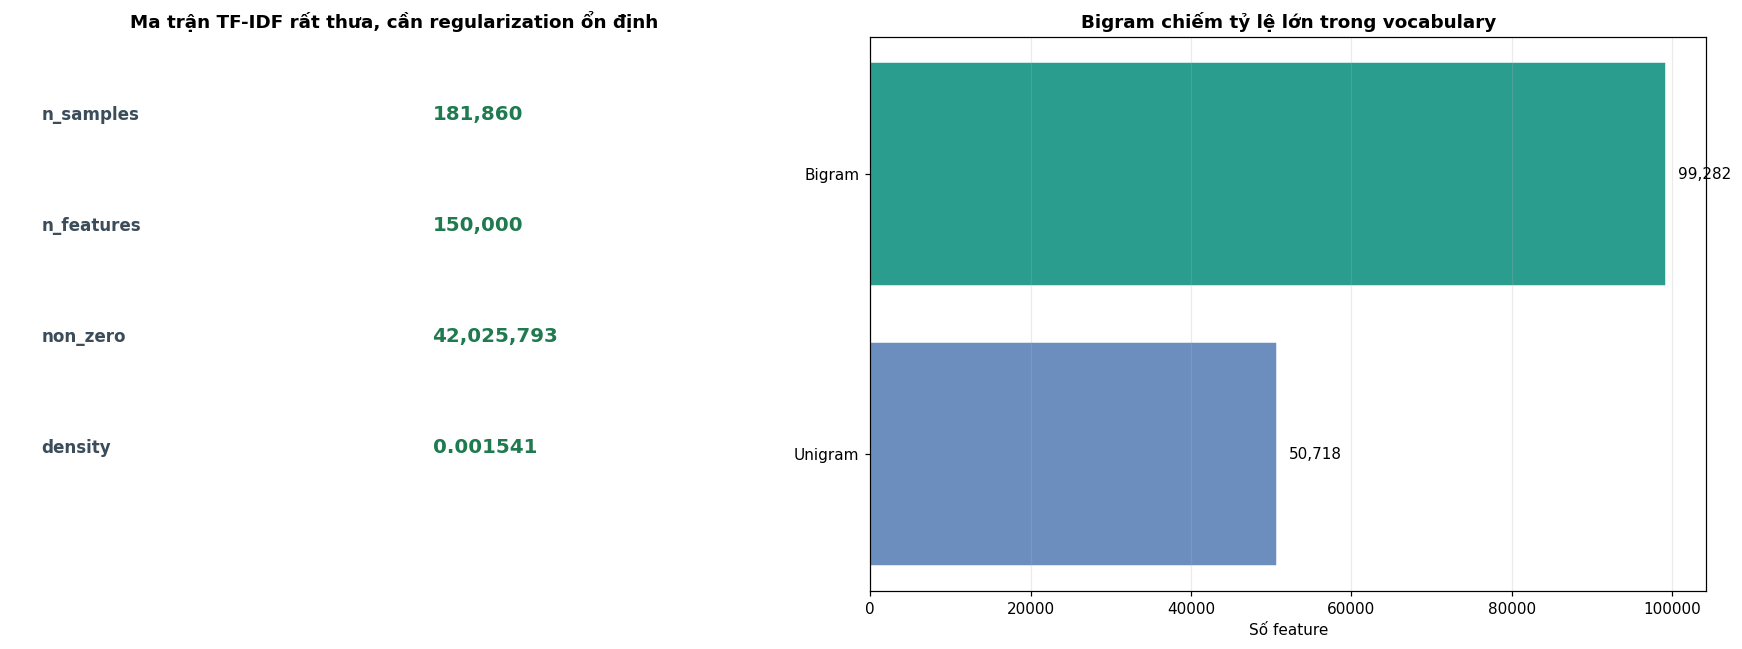


  n_samples : 181,860
  n_features: 150,000
  non_zero  : 42,025,793
  density   : 0.001541


In [18]:
# -- 4.3 TF-IDF summary ---------------------------------------------------------
_feat = vectorizer.get_feature_names_out()
_n_features = len(_feat)
_n_uni = sum(1 for t in _feat if "_" not in t)
_n_bi = _n_features - _n_uni
_n_samples = int(X_train.shape[0])
_nnz = int(X_train.nnz)
_density = float(_nnz / (X_train.shape[0] * X_train.shape[1])) if X_train.shape[0] * X_train.shape[1] > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.1, 1.2]})

axes[0].axis("off")
_cards = [
    ("n_samples", f"{_n_samples:,}"),
    ("n_features", f"{_n_features:,}"),
    ("non_zero", f"{_nnz:,}"),
    ("density", f"{_density:.6f}"),
]
for i, (k, v) in enumerate(_cards):
    y = 0.85 - i * 0.2
    axes[0].text(0.04, y, k, fontsize=11, color="#3b4c5a", weight="bold")
    axes[0].text(0.55, y, v, fontsize=13, color="#1f7a4f", weight="bold")
axes[0].set_title("Ma trận TF-IDF rất thưa, cần regularization ổn định", fontweight="bold")

bars = axes[1].barh(["Unigram", "Bigram"], [_n_uni, _n_bi], color=["#6c8ebf", "#2a9d8f"], edgecolor="white")
for b in bars:
    axes[1].text(b.get_width() + _n_features * 0.01, b.get_y() + b.get_height()/2,
                 f"{int(b.get_width()):,}", va="center", fontsize=10)
axes[1].set_xlabel("Số feature")
axes[1].set_title("Bigram chiếm tỷ lệ lớn trong vocabulary", fontweight="bold")
axes[1].grid(axis="x", alpha=0.25)

fig.tight_layout()
save_fig(fig, "03_tfidf_vocab.png")

print(f"\n  n_samples : {_n_samples:,}")
print(f"  n_features: {_n_features:,}")
print(f"  non_zero  : {_nnz:,}")
print(f"  density   : {_density:.6f}")


---
## Section 5 - Huấn Luyện Mô Hình

**LinearSVC** là mô hình SVM dùng cấu hình mặc định của `sklearn.svm.LinearSVC` cho phân loại văn bản trên ma trận TF-IDF.

| Tham số | Giá trị | Lý do |
|---------|---------|-------|
| `C` | 1.5 | Cân bằng regularization / fit |
| `class_weight` | balanced | Tự động điều chỉnh trọng số theo tỷ lệ class trong tập train |
| `probability` | False | App sẽ suy ra confidence từ `decision_function` |

In [19]:
# -- 5.1 Train / load model results ---------------------------------------------
MODEL_NAME = "LinearSVC"

if os.path.exists(MODEL_RESULTS_PATH):
    log("Cache ket qua ton tai, dang tai...", "OK")
    with open(MODEL_RESULTS_PATH, "rb") as f:
        _res = pickle.load(f)
elif os.path.exists(PIPELINE_PATH):
    log("Đã có inference_pipeline.pkl, bỏ qua train và predict lại tập test...", "OK")
    with open(PIPELINE_PATH, "rb") as f:
        _pipeline_cached = pickle.load(f)

    _model = _pipeline_cached["model"]
    _t1 = time.time()
    _y_pred = _model.predict(X_test)
    log(f"Dự đoán xong! ({time.time()-_t1:.1f}s)", "OK")

    _acc = accuracy_score(y_test, _y_pred)
    _f1w = f1_score(y_test, _y_pred, average="weighted")
    _f1m = f1_score(y_test, _y_pred, average="macro")
    _f1p = f1_score(y_test, _y_pred, labels=classes, average=None)

    _cfg = dict(_pipeline_cached.get("config", {}))
    _cfg.setdefault("model_name", MODEL_NAME)
    _cfg.setdefault("C", C_VALUE)
    _cfg.setdefault("max_features", MAX_FEATURES)
    _cfg.setdefault("ngram_range", NGRAM_RANGE)
    _cfg.setdefault("min_df", MIN_DF)
    _cfg.setdefault("class_weight", CLASS_WEIGHT)
    _cfg.setdefault("test_size", TEST_SIZE)
    _cfg.setdefault("n_train", X_train.shape[0])
    _cfg.setdefault("n_test", X_test.shape[0])
    _cfg["probability"] = False

    _res = {
        "model":        _model,
        "y_pred":       _y_pred,
        "y_test":       y_test.values,
        "accuracy":     _acc,
        "f1_weighted":  _f1w,
        "f1_macro":     _f1m,
        "f1_per_class": dict(zip(classes, _f1p)),
        "classes":      classes,
        "train_time":   0,
        "config":       _cfg,
    }
    with open(MODEL_RESULTS_PATH, "wb") as f:
        pickle.dump(_res, f)
    log(f"Đã lưu lại model_results: {MODEL_RESULTS_PATH}", "SAVE")
else:
    log(f"Huấn luyện {MODEL_NAME} (C={C_VALUE})...")
    _model = LinearSVC(
        C=C_VALUE,
        class_weight=CLASS_WEIGHT,
        random_state=RANDOM_STATE,
    )

    _t0       = time.time()
    _ts_start = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{_ts_start}] Bắt đầu train ({X_train.shape[0]:,} mẫu)...", flush=True)
    _model.fit(X_train, y_train)

    _train_dur = time.time() - _t0
    _th, _tr   = divmod(int(_train_dur), 3600)
    _tm, _ts   = divmod(_tr, 60)
    _dur_str   = f"{_th}h {_tm:02d}m {_ts:02d}s" if _th else f"{_tm}m {_ts:02d}s"
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Huấn luyện xong! {_dur_str}", flush=True)

    log("Dự đoán trên tập test...")
    _t1     = time.time()
    _y_pred = _model.predict(X_test)
    log(f"Dự đoán xong! ({time.time()-_t1:.1f}s)", "OK")

    _acc = accuracy_score(y_test, _y_pred)
    _f1w = f1_score(y_test, _y_pred, average="weighted")
    _f1m = f1_score(y_test, _y_pred, average="macro")
    _f1p = f1_score(y_test, _y_pred, labels=classes, average=None)

    _res = {
        "model":        _model,
        "y_pred":       _y_pred,
        "y_test":       y_test.values,
        "accuracy":     _acc,
        "f1_weighted":  _f1w,
        "f1_macro":     _f1m,
        "f1_per_class": dict(zip(classes, _f1p)),
        "classes":      classes,
        "train_time":   _train_dur,
        "config": {
            "model_name":   MODEL_NAME,
            "kernel":       "default",
            "probability":  False,
            "C":            C_VALUE,
            "class_weight":  CLASS_WEIGHT,
            "max_features": MAX_FEATURES,
            "ngram_range":  NGRAM_RANGE,
            "min_df":       MIN_DF,
            "test_size":    TEST_SIZE,
            "n_train":      X_train.shape[0],
            "n_test":       X_test.shape[0],
        },
    }
    with open(MODEL_RESULTS_PATH, "wb") as f:
        pickle.dump(_res, f)
    log(f"Đã lưu: {MODEL_RESULTS_PATH}", "SAVE")

# Expose sang scope toan cuc
y_pred       = _res["y_pred"]
y_test_arr   = _res["y_test"]
model_acc    = _res["accuracy"]
model_f1w    = _res["f1_weighted"]
model_f1m    = _res["f1_macro"]
f1_per_class = _res["f1_per_class"]
classes      = _res["classes"]
_train_time  = _res.get("train_time", 0)

_h, _rem = divmod(int(_train_time), 3600)
_m, _s   = divmod(_rem, 60)
_dur_disp = f"{_h}h {_m:02d}m {_s:02d}s" if _h else f"{_m}m {_s:02d}s" if _m else f"{_s}s"

SEP = "=" * 55
print(f"\n{SEP}")
print(f"  {MODEL_NAME} -- C={_res['config'].get('C', C_VALUE)}  max_features={_res['config'].get('max_features', MAX_FEATURES):,}")
print(f"  class_weight : {_res['config'].get('class_weight', CLASS_WEIGHT)}")
print(f"  probability  : N/A (LinearSVC)")
print(f"  Thời gian train : {_dur_disp}")
print(f"  {chr(45)*52}")
print(f"  Accuracy   : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
print(f"{SEP}")


[11:34:14] [i] Huấn luyện LinearSVC (C=1.5)...
[11:34:14] Bắt đầu train (181,860 mẫu)...
[11:36:04] Huấn luyện xong! 1m 49s
[11:36:04] [i] Dự đoán trên tập test...
[11:36:04] [OK] Dự đoán xong! (0.1s)
[11:36:04] [SAVE] Đã lưu: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\model\model_results.pkl

  LinearSVC -- C=1.5  max_features=150,000
  class_weight : balanced
  probability  : N/A (LinearSVC)
  Thời gian train : 1m 49s
  ----------------------------------------------------
  Accuracy   : 0.8900  (89.00%)
  F1-weighted: 0.8898
  F1-macro   : 0.8787


---
## Section 6 - Đánh Giá Mô Hình

Báo cáo phân loại, ma trận nhầm lẫn và F1 theo từng chủ đề.

In [20]:
# -- 6.1 Báo cáo phân loại -----------------------------------------------
# --
if "y_pred" not in dir():
    with open(MODEL_RESULTS_PATH, "rb") as f:
        _res = pickle.load(f)
    y_pred       = _res["y_pred"]; y_test_arr = _res["y_test"]
    model_acc    = _res["accuracy"]; model_f1w = _res["f1_weighted"]
    model_f1m    = _res["f1_macro"]; f1_per_class = _res["f1_per_class"]
    classes      = _res["classes"]

_report = classification_report(y_test_arr, y_pred, target_names=classes, digits=4)

print(f"{'='*65}")
print(f"  CLASSIFICATION REPORT")
print(f"  Mô hình : LinearSVC  C={_res['config']['C']}"
      f"  max_features={_res['config']['max_features']:,}")
print(f"  Dữ liệu : Train {_res['config']['n_train']:,}  |  Test {_res['config']['n_test']:,}")
print(f"  class_weight : {_res['config'].get('class_weight', CLASS_WEIGHT)}")
print(f"  {'-'*62}")
print(f"  Accuracy   : {model_acc:.4f}")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
print(f"{'='*65}")
print(_report)

_rp = os.path.join(RESULTS_DIR, "classification_report.txt")
with open(_rp, "w", encoding="utf-8") as f:
    f.write(f"LinearSVC C={_res['config']['C']} "
            f"max_features={_res['config']['max_features']:,}\n")
    f.write(f"class_weight: {_res['config'].get('class_weight', CLASS_WEIGHT)}\n")
    f.write(f"Accuracy: {model_acc:.4f}\n")
    f.write(f"F1-weighted: {model_f1w:.4f}\n")
    f.write(f"F1-macro: {model_f1m:.4f}\n\n")
    f.write(_report)
log(f"Saved: {_rp}", "SAVE")

  CLASSIFICATION REPORT
  Mô hình : LinearSVC  C=1.5  max_features=150,000
  Dữ liệu : Train 181,860  |  Test 32,094
  class_weight : balanced
  --------------------------------------------------------------
  Accuracy   : 0.8900
  F1-weighted: 0.8898
  F1-macro   : 0.8787
                        precision    recall  f1-score   support

               Bạn đọc     0.9690    0.9174    0.9425      1876
Bảo vệ người tiêu dùng     0.8442    0.8210    0.8325       581
          Bất động sản     0.8977    0.9216    0.9095      1876
             Chính trị     0.8734    0.8859    0.8796      1876
             Công nghệ     0.9085    0.9099    0.9092      1876
               Du lịch     0.8402    0.8664    0.8531      1602
    Dân tộc - Tôn giáo     0.6858    0.7117    0.6985       503
              Giáo dục     0.9109    0.9152    0.9131      1876
            Kinh doanh     0.8150    0.7916    0.8031      1876
             Pháp luật     0.8701    0.8998    0.8847      1876
              Sức khỏ

[11:36:06] [SAVE] Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\results\04_confusion_matrix.png


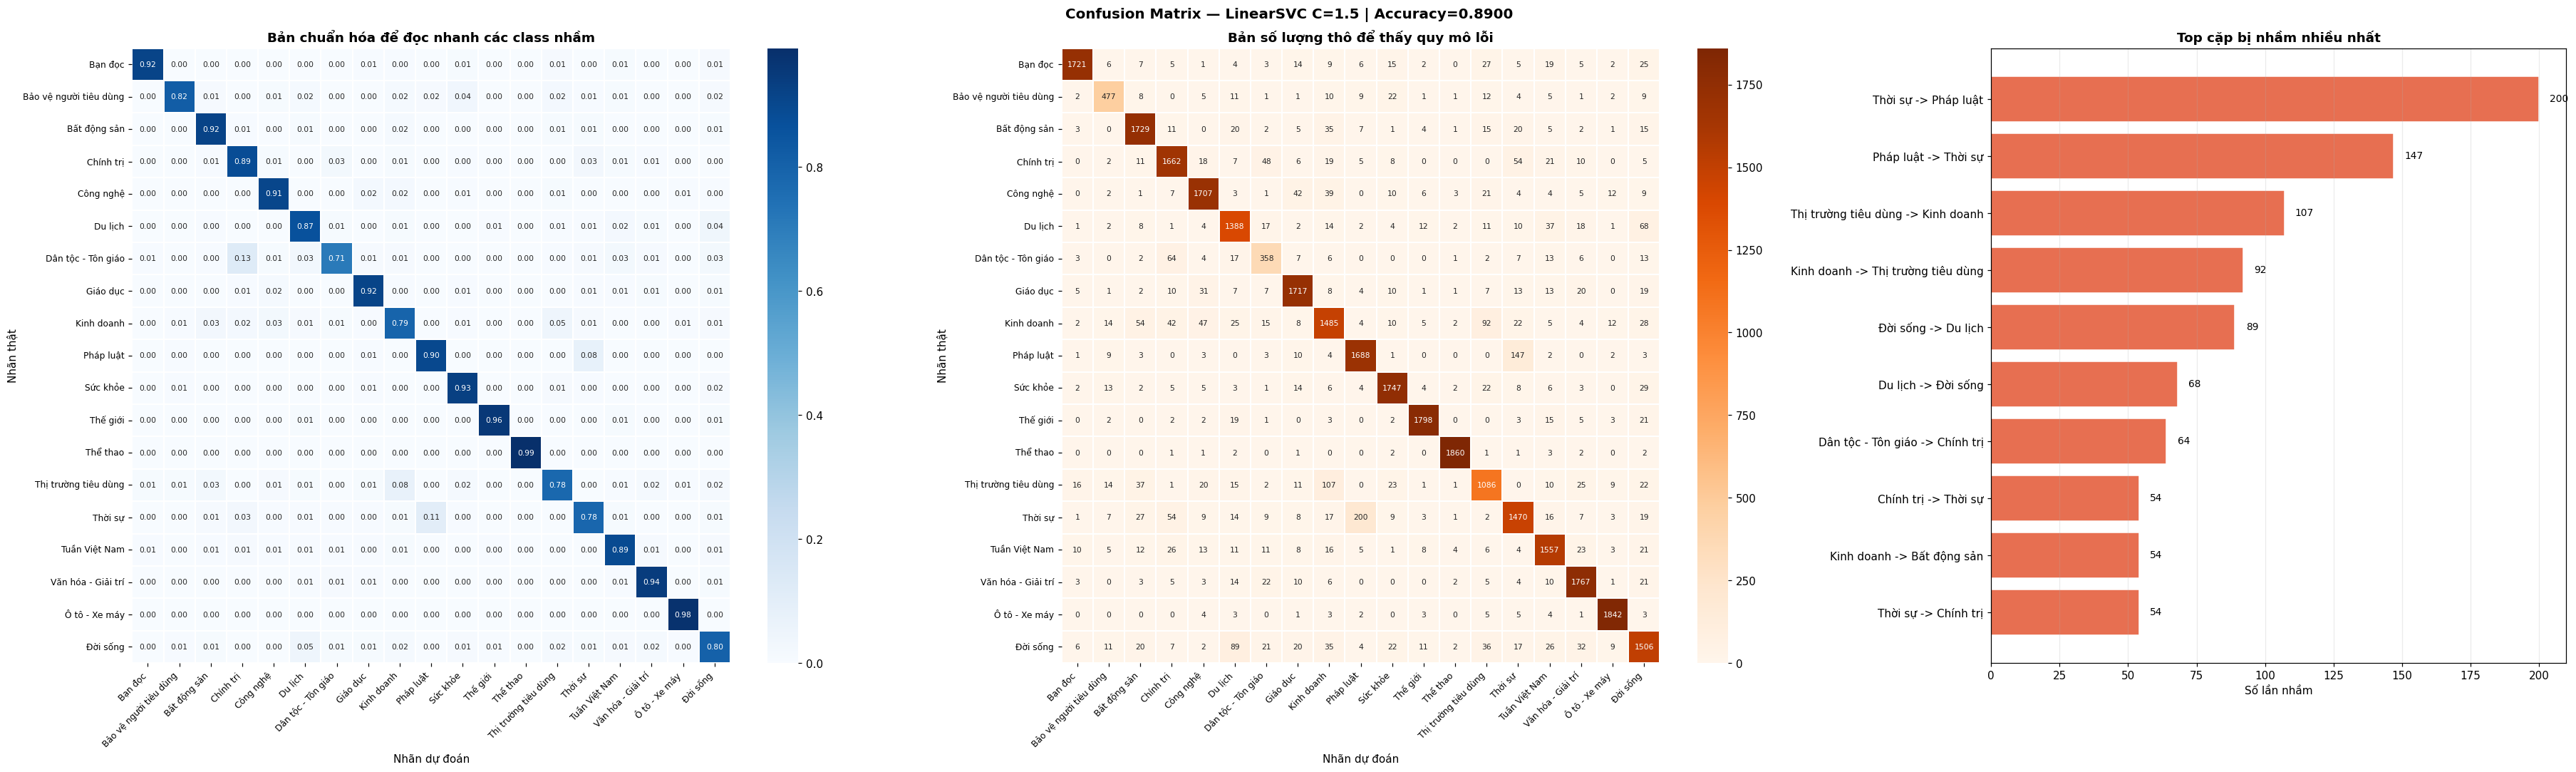

In [21]:
# -- 6.2 Confusion matrix + top confusion pairs --------------------------------
_cm = confusion_matrix(y_test_arr, y_pred, labels=classes)
_cmn = _cm.astype(float) / np.clip(_cm.sum(axis=1, keepdims=True), 1, None)

_pairs = []
for i, t in enumerate(classes):
    for j, p in enumerate(classes):
        if i == j:
            continue
        c = int(_cm[i, j])
        if c > 0:
            _pairs.append((f"{t} -> {p}", c))
_top_pairs = sorted(_pairs, key=lambda x: x[1], reverse=True)[:10]

fig, axes = plt.subplots(1, 3, figsize=(33, 10), gridspec_kw={"width_ratios": [1.3, 1.3, 1.0]})

sns.heatmap(_cmn, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.25, linecolor="white", ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Bản chuẩn hóa để đọc nhanh các class nhầm", fontweight="bold")
axes[0].set_xlabel("Nhãn dự đoán")
axes[0].set_ylabel("Nhãn thật")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(axes[0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(_cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.25, linecolor="white", ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("Bản số lượng thô để thấy quy mô lỗi", fontweight="bold")
axes[1].set_xlabel("Nhãn dự đoán")
axes[1].set_ylabel("Nhãn thật")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=8)

if _top_pairs:
    _labels = [x[0] for x in _top_pairs][::-1]
    _vals = [x[1] for x in _top_pairs][::-1]
    _bars = axes[2].barh(_labels, _vals, color="#e76f51", edgecolor="white")
    for b, v in zip(_bars, _vals):
        axes[2].text(v + max(_vals) * 0.02, b.get_y() + b.get_height()/2, f"{v}", va="center", fontsize=9)
    axes[2].set_title("Top cặp bị nhầm nhiều nhất", fontweight="bold")
    axes[2].set_xlabel("Số lần nhầm")
    axes[2].grid(axis="x", alpha=0.25)
else:
    axes[2].axis("off")

fig.suptitle(f"Confusion Matrix — LinearSVC C={C_VALUE} | Accuracy={model_acc:.4f}",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "04_confusion_matrix.png")


[11:36:07] [SAVE] Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\results\05_f1_per_class.png


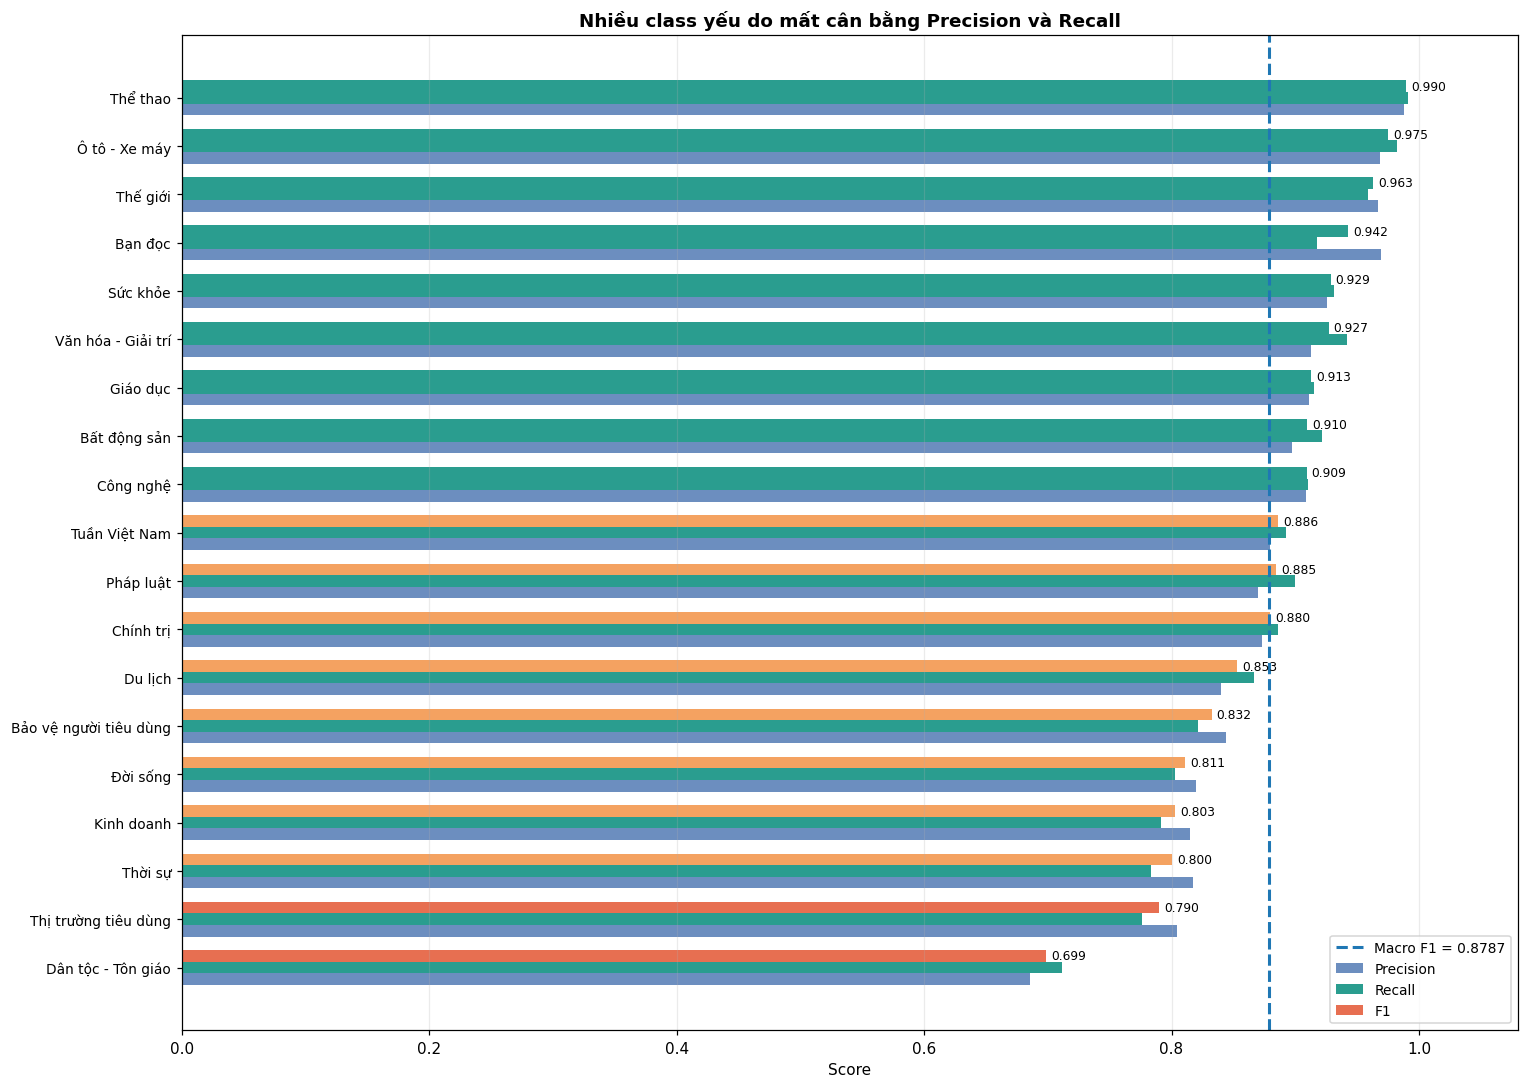

[11:36:07] [SAVE] Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\results\06_support_vs_f1.png


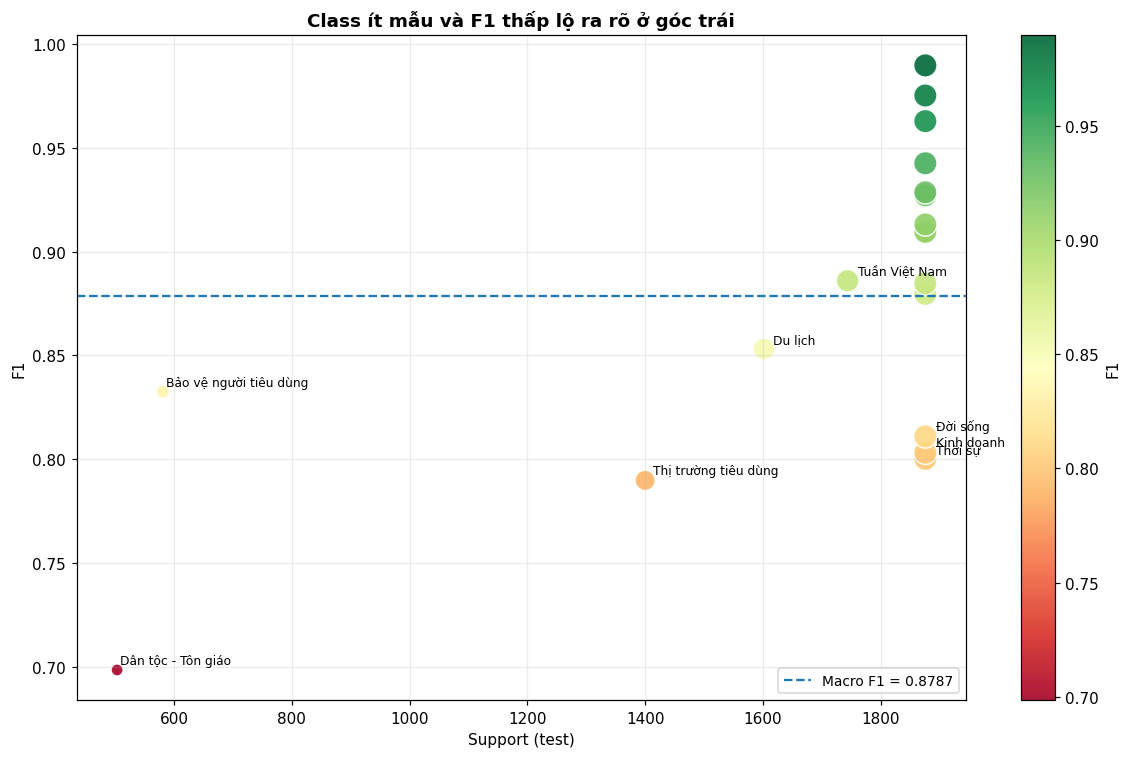

In [22]:
# -- 6.3 P/R/F1 by class + support vs F1 ---------------------------------------
_report_dict = classification_report(
    y_test_arr, y_pred, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_diag_rows = []
for cls in classes:
    _diag_rows.append({
        "class": cls,
        "precision": _report_dict[cls]["precision"],
        "recall": _report_dict[cls]["recall"],
        "f1": _report_dict[cls]["f1-score"],
        "support": int(_report_dict[cls]["support"]),
    })
_prf = pd.DataFrame(_diag_rows).sort_values("f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))
_y = np.arange(len(_prf))
_h = 0.24

ax.barh(_y - _h, _prf["precision"], height=_h, color="#6c8ebf", label="Precision")
ax.barh(_y,       _prf["recall"],    height=_h, color="#2a9d8f", label="Recall")
_bf1 = ax.barh(_y + _h, _prf["f1"],  height=_h,
               color=["#e76f51" if v < 0.80 else "#f4a261" if v < 0.90 else "#2a9d8f" for v in _prf["f1"]],
               label="F1")

for b, v in zip(_bf1, _prf["f1"]):
    ax.text(v + 0.004, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=8)

ax.axvline(model_f1m, color="#1f77b4", ls="--", lw=2, label=f"Macro F1 = {model_f1m:.4f}")
ax.set_yticks(_y)
ax.set_yticklabels(_prf["class"], fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel("Score")
ax.set_title("Nhiều class yếu do mất cân bằng Precision và Recall", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
save_fig(fig, "05_f1_per_class.png")

fig2, ax2 = plt.subplots(figsize=(11, 7))
_sc = ax2.scatter(_prf["support"], _prf["f1"],
                  s=np.clip(_prf["support"] / 8, 30, 260),
                  c=_prf["f1"], cmap="RdYlGn", edgecolor="white", alpha=0.9)
for _, r in _prf.iterrows():
    if r["support"] < _prf["support"].quantile(0.25) or r["f1"] < 0.85:
        ax2.text(r["support"] * 1.01, r["f1"] + 0.003, r["class"], fontsize=8)
ax2.axhline(model_f1m, color="#1f77b4", ls="--", lw=1.5, label=f"Macro F1 = {model_f1m:.4f}")
ax2.set_xlabel("Support (test)")
ax2.set_ylabel("F1")
ax2.set_title("Class ít mẫu và F1 thấp lộ ra rõ ở góc trái", fontweight="bold")
ax2.grid(alpha=0.25)
ax2.legend(loc="lower right", fontsize=9)
fig2.colorbar(_sc, ax=ax2, label="F1")
fig2.tight_layout()
save_fig(fig2, "06_support_vs_f1.png")


In [23]:
# -- 6.4 Tóm tắt kết quả -------------------------------------------------
print(f"\n{'='*60}")
print(f"  KẾT QUẢ MÔ HÌNH PHÂN LOẠI TIN TỨC VIETNAMNET")
print(f"{'='*60}")
print(f"\n  [CẤU HÌNH MÔ HÌNH]")
print(f"    Thuật toán   : LinearSVC")
print(f"    C            : {_res['config']['C']}")
print(f"    class_weight : {_res['config'].get('class_weight', CLASS_WEIGHT)}")
print(f"    probability  : N/A (LinearSVC)")

print(f"\n  [CẤU HÌNH TF-IDF]")
print(f"    max_features : {_res['config']['max_features']:,}")
print(f"    ngram_range  : {_res['config']['ngram_range']}")
print(f"    min_df       : {_res['config']['min_df']}")
print(f"    sublinear_tf : True")

print(f"\n  [DỮ LIỆU]")
print(f"    Số chủ đề    : {len(classes)}")
print(f"    Train        : {_res['config']['n_train']:,} bài ({(1-TEST_SIZE)*100:.0f}%)")
print(f"    Test         : {_res['config']['n_test']:,} bài  ({TEST_SIZE*100:.0f}%)")

print(f"\n  [HIỆU NĂNG TRÊN TẬP TEST]")
print(f"    Accuracy     : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"    F1-weighted  : {model_f1w:.4f}")
print(f"    F1-macro     : {model_f1m:.4f}")

print(f"\n  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1])[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")

print(f"\n  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")

_cm2 = confusion_matrix(y_test_arr, y_pred, labels=classes)
_confused = sorted(
    [(_cm2[i, j], classes[i], classes[j])
     for i in range(len(classes)) for j in range(len(classes)) if i != j and _cm2[i,j] > 0],
    reverse=True
)
print(f"\n  [TOP 5 CẶP CHỦ ĐỀ BỊ NHẦM NHIỀU NHẤT]")
for _cnt, _tr, _pr in _confused[:5]:
    print(f"    {_tr:<28} -> {_pr:<28}  {_cnt:>4} lần")

print(f"\n  [FILE KẾT QUẢ ĐÃ LƯU]")
for _f in sorted(os.listdir(RESULTS_DIR)):
    _fp = os.path.join(RESULTS_DIR, _f)
    print(f"    {_f:<35}  ({os.path.getsize(_fp)/1024:.1f} KB)")
print(f"\n{'='*60}")


  KẾT QUẢ MÔ HÌNH PHÂN LOẠI TIN TỨC VIETNAMNET

  [CẤU HÌNH MÔ HÌNH]
    Thuật toán   : LinearSVC
    C            : 1.5
    class_weight : balanced
    probability  : N/A (LinearSVC)

  [CẤU HÌNH TF-IDF]
    max_features : 150,000
    ngram_range  : (1, 2)
    min_df       : 2
    sublinear_tf : True

  [DỮ LIỆU]
    Số chủ đề    : 19
    Train        : 181,860 bài (85%)
    Test         : 32,094 bài  (15%)

  [HIỆU NĂNG TRÊN TẬP TEST]
    Accuracy     : 0.8900  (89.00%)
    F1-weighted  : 0.8898
    F1-macro     : 0.8787

  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]
    Dân tộc - Tôn giáo                      F1 = 0.6985
    Thị trường tiêu dùng                    F1 = 0.7898
    Thời sự                                 F1 = 0.8002
    Kinh doanh                              F1 = 0.8031
    Đời sống                                F1 = 0.8110

  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]
    Thể thao                                F1 = 0.9896
    Ô tô - Xe máy                           F1 = 0.9751
    Thế giới 

---
## Section 7 - Export Inference Pipeline

Đóng gói toàn bộ pipeline suy luận vào **một file duy nhất** (`inference_pipeline.pkl`) để tái sử dụng cho inference.

File chứa: `vectorizer` + `model` + `stopwords` + `classes` + `config`.

> **Quan trọng**: khi inference, tiền xử lý văn bản đầu vào phải **khớp chính xác** với pipeline training:
> `(title + " " + title + " " + title + " " + content)` -> lowercase -> strip punct -> strip digits -> ViTokenizer -> loại stopwords -> `vectorizer.transform()`

In [24]:
# -- 7.1 Export inference pipeline --------------------------------------
_pipeline = {
    "vectorizer": vectorizer,
    "model":      _res["model"],
    "stopwords":  sorted(STOPWORDS),
    "classes":    classes,
    "config": {
        "title_weight":  3,             # title lặp 3 lần trước content
        "lowercase":     True,
        "remove_punct":  True,          # re.sub(r"[^\w\s]", " ")
        "remove_digits": True,          # re.sub(r"\d+", " ")
        "tokenizer":     "pyvi.ViTokenizer",
        "model_name":    MODEL_NAME,
        "kernel":        "default",
        "probability":   False,
        "max_features":  MAX_FEATURES,
        "ngram_range":   NGRAM_RANGE,
        "min_df":        MIN_DF,
        "sublinear_tf":  True,
        "C":             C_VALUE,
        "class_weight":  CLASS_WEIGHT,
    },
}

with open(PIPELINE_PATH, "wb") as f:
    pickle.dump(_pipeline, f)
log(f"Đã lưu: {PIPELINE_PATH}  ({os.path.getsize(PIPELINE_PATH)/1e6:.1f} MB)", "SAVE")

# --
with open(PIPELINE_PATH, "rb") as f:
    _p = pickle.load(f)

def _predict_one(title, content, pipeline):
    from pyvi import ViTokenizer
    sw    = set(pipeline["stopwords"])
    text  = (str(title) + " " + str(title) + " " + str(title) + " " + str(content)).lower()
    text  = re.sub(r"[^\w\s]", " ", text)
    text  = re.sub(r"\d+",     " ", text)
    text  = ViTokenizer.tokenize(text)
    clean = re.sub(r"\s+", " ", " ".join(t for t in text.split() if t not in sw)).strip()
    vec   = pipeline["vectorizer"].transform([clean])
    return pipeline["model"].predict(vec)[0]

print(f"\n  [SMOKE TEST - 3 bài ngẫu nhiên từ df_raw]\n")
_rng = np.random.default_rng(99)
_ok  = 0
for _i in _rng.choice(len(df_raw), size=3, replace=False):
    _row  = df_raw.iloc[_i]
    _pred = _predict_one(_row["title"], _row["content"], _p)
    _ok  += int(_pred == _row["label"])
    _mark = "[OK]" if _pred == _row["label"] else "[LỖI]"
    print(f"  {_mark}  Thật: {_row['label']:<32}  Dự đoán: {_pred}")
print(f"\n  Kết quả smoke test: {_ok}/3")


[11:36:08] [SAVE] Đã lưu: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\SVM\model\inference_pipeline.pkl  (29.7 MB)

  [SMOKE TEST - 3 bài ngẫu nhiên từ df_raw]

  [OK]  Thật: Thể thao                          Dự đoán: Thể thao
  [OK]  Thật: Văn hóa - Giải trí                Dự đoán: Văn hóa - Giải trí
  [OK]  Thật: Ô tô - Xe máy                     Dự đoán: Ô tô - Xe máy

  Kết quả smoke test: 3/3


---
## Section 8 - Chẩn Đoán

Section nay chi print ra cac tin hieu can xem de cai thien model, không train them.


In [25]:
# -- 8.1 Per-class metric table ---------------------------------------------
if "y_pred" not in dir():
    with open(MODEL_RESULTS_PATH, "rb") as f:
        _res = pickle.load(f)
    y_pred       = _res["y_pred"]; y_test_arr = _res["y_test"]
    model_acc    = _res["accuracy"]; model_f1w = _res["f1_weighted"]
    model_f1m    = _res["f1_macro"]; f1_per_class = _res["f1_per_class"]
    classes      = _res["classes"]

_diag_report = classification_report(
    y_test_arr, y_pred, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_diag_df = pd.DataFrame([
    {
        "class": cls,
        "precision": _diag_report[cls]["precision"],
        "recall":    _diag_report[cls]["recall"],
        "f1":        _diag_report[cls]["f1-score"],
        "support":   int(_diag_report[cls]["support"]),
    }
    for cls in classes
])
_diag_df["pr_gap"] = _diag_df["recall"] - _diag_df["precision"]
_diag_df["support_pct"] = _diag_df["support"] / max(int(_diag_df["support"].sum()), 1)

print(f"\n{'='*88}")
print("[TÓM TẮT CHẨN ĐOÁN SVM]")
print(f"  Accuracy    : {model_acc:.4f}")
print(f"  F1-weighted : {model_f1w:.4f}")
print(f"  F1-macro    : {model_f1m:.4f}")
print(f"  Chênh lệch (w-m): {model_f1w - model_f1m:+.4f}")
print(f"{'='*88}")

print("\n[5 CHỦ ĐỀ YẾU NHẤT THEO F1]")
for _, r in _diag_df.sort_values(["f1", "support"], ascending=[True, True]).head(5).iterrows():
    print(f"  {r['class']:<30}  F1={r['f1']:.4f}  P={r['precision']:.4f}  R={r['recall']:.4f}  số_mẫu={int(r['support'])}")

print("\n[5 CHỦ ĐỀ ÍT MẪU NHẤT TRONG TẬP TEST]")
for _, r in _diag_df.sort_values(["support", "f1"], ascending=[True, True]).head(5).iterrows():
    print(f"  {r['class']:<30}  số_mẫu={int(r['support']):>5}  ({r['support_pct']*100:>5.2f}%)  F1={r['f1']:.4f}")

print("\n[CÁC CHỦ ĐỀ CÓ RECALL THẤP HƠN PRECISION]")
for _, r in _diag_df.sort_values("pr_gap", ascending=True).head(5).iterrows():
    print(f"  {r['class']:<30}  độ_lệch={r['pr_gap']:+.4f}  P={r['precision']:.4f}  R={r['recall']:.4f}")

print("\n[CÁC CHỦ ĐỀ CÓ PRECISION THẤP HƠN RECALL]")
for _, r in _diag_df.sort_values("pr_gap", ascending=False).head(5).iterrows():
    print(f"  {r['class']:<30}  độ_lệch={r['pr_gap']:+.4f}  P={r['precision']:.4f}  R={r['recall']:.4f}")

# -- 8.2 Top confusion pairs ------------------------------------------------
_cm_diag = confusion_matrix(y_test_arr, y_pred, labels=classes)
_pairs = []
for i, true_cls in enumerate(classes):
    _support = max(int(_cm_diag[i].sum()), 1)
    for j, pred_cls in enumerate(classes):
        if i == j or _cm_diag[i, j] == 0:
            continue
        _pairs.append({
            "count": int(_cm_diag[i, j]),
            "rate":  float(_cm_diag[i, j] / _support),
            "true":  true_cls,
            "pred":  pred_cls,
        })
_pairs_df = pd.DataFrame(_pairs).sort_values(["count", "rate"], ascending=[False, False]) if _pairs else pd.DataFrame(columns=["count", "rate", "true", "pred"])

print("\n[TOP 8 CẶP CHỦ ĐỀ BỊ NHẦM NHIỀU NHẤT]")
if len(_pairs_df) == 0:
    print("  Không có cặp nhầm lẫn ngoài đường chéo.")
else:
    for _, r in _pairs_df.head(8).iterrows():
        print(f"  {r['true']:<28} -> {r['pred']:<28}  {int(r['count']):>4} lần  ({r['rate']*100:>5.2f}%)")

# -- 8.3 Next-step hints ----------------------------------------------------
print("\n[GỢI Ý BƯỚC TIẾP THEO CHO SVM]")
if (model_f1w - model_f1m) > 0.06:
    print("  - Weighted cao hơn macro khá nhiều -> dữ liệu vẫn lệch lớp rõ; hãy kiểm tra trước các lớp có ít mẫu.")
else:
    print("  - Chênh lệch giữa weighted và macro không lớn -> nên tập trung vào các cặp nhầm lẫn cụ thể.")

_low_recall = _diag_df[_diag_df["pr_gap"] < -0.08].sort_values("f1").head(3)["class"].tolist()
_low_precision = _diag_df[_diag_df["pr_gap"] > 0.08].sort_values("f1").head(3)["class"].tolist()
_very_low_f1 = _diag_df[_diag_df["f1"] < 0.80].sort_values("f1")["class"].tolist()

if _low_recall:
    print(f"  - Các lớp có recall thấp: {', '.join(_low_recall)}")
    print("    Hãy thử tăng nhẹ class weight, bổ sung dữ liệu, hoặc mở rộng bigram/max_features nếu từ vựng còn yếu.")
if _low_precision:
    print(f"  - Các lớp có precision thấp: {', '.join(_low_precision)}")
    print("    Hãy xem lại các lớp bị dự đoán quá nhiều; cân nhắc giảm class weight hoặc kiểm tra các cặp nhầm lẫn.")
if _very_low_f1:
    print(f"  - Các lớp có F1 < 0.80: {', '.join(_very_low_f1[:6])}{' ...' if len(_very_low_f1) > 6 else ''}")
    print("    Ưu tiên bổ sung dữ liệu hoặc cải thiện khả năng tách feature giữa tiêu đề và nội dung cho nhóm này.")

if "X_train" in dir():
    _density = float(X_train.nnz / (X_train.shape[0] * X_train.shape[1])) if X_train.shape[0] * X_train.shape[1] > 0 else 0.0
    print(f"  - Ma trận TF-IDF train: {X_train.shape[0]:,} x {X_train.shape[1]:,}  |  density = {_density:.6f}")
    print("    Nếu huấn luyện quá chậm, hãy giảm max_features hoặc thử feature selection / SVD trước khi dùng mô hình nặng hơn.")

print("  - Nếu nhầm lẫn tập trung ở vài cặp, hãy kiểm tra trực tiếp các cặp đó trước khi tinh chỉnh toàn cục.")
print("  - Nếu SVM đã tinh chỉnh khá ổn nhưng macro F1 vẫn thấp, hãy giữ nó làm baseline và đẩy các ca khó sang PhoBERT hoặc mô hình kết hợp.")



[TÓM TẮT CHẨN ĐOÁN SVM]
  Accuracy    : 0.8900
  F1-weighted : 0.8898
  F1-macro    : 0.8787
  Chênh lệch (w-m): +0.0111

[5 CHỦ ĐỀ YẾU NHẤT THEO F1]
  Dân tộc - Tôn giáo              F1=0.6985  P=0.6858  R=0.7117  số_mẫu=503
  Thị trường tiêu dùng            F1=0.7898  P=0.8044  R=0.7757  số_mẫu=1400
  Thời sự                         F1=0.8002  P=0.8176  R=0.7836  số_mẫu=1876
  Kinh doanh                      F1=0.8031  P=0.8150  R=0.7916  số_mẫu=1876
  Đời sống                        F1=0.8110  P=0.8194  R=0.8028  số_mẫu=1876

[5 CHỦ ĐỀ ÍT MẪU NHẤT TRONG TẬP TEST]
  Dân tộc - Tôn giáo              số_mẫu=  503  ( 1.57%)  F1=0.6985
  Bảo vệ người tiêu dùng          số_mẫu=  581  ( 1.81%)  F1=0.8325
  Thị trường tiêu dùng            số_mẫu= 1400  ( 4.36%)  F1=0.7898
  Du lịch                         số_mẫu= 1602  ( 4.99%)  F1=0.8531
  Tuần Việt Nam                   số_mẫu= 1744  ( 5.43%)  F1=0.8859

[CÁC CHỦ ĐỀ CÓ RECALL THẤP HƠN PRECISION]
  Bạn đọc                         độ_lệch=-